# Multiple Linear Regression: Toyota Corolla Price


## Assignment Explanation

### Objective
The objective of this assignment is to predict Toyota Corolla price using Multiple Linear Regression and compare regularized regression models.

### Methodology
The dataset is explored and Price is selected as the target variable. Numerical and categorical features are preprocessed separately. The data is split into training and testing sets. Linear Regression, Ridge Regression, and Lasso Regression are trained and compared using R2, MAE, and RMSE.

### Interpretation
Multiple Linear Regression estimates how different vehicle attributes affect price. Ridge and Lasso add regularization to reduce overfitting. The best model is the one with higher R2 and lower error values on test data.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.shape

(1436, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [7]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

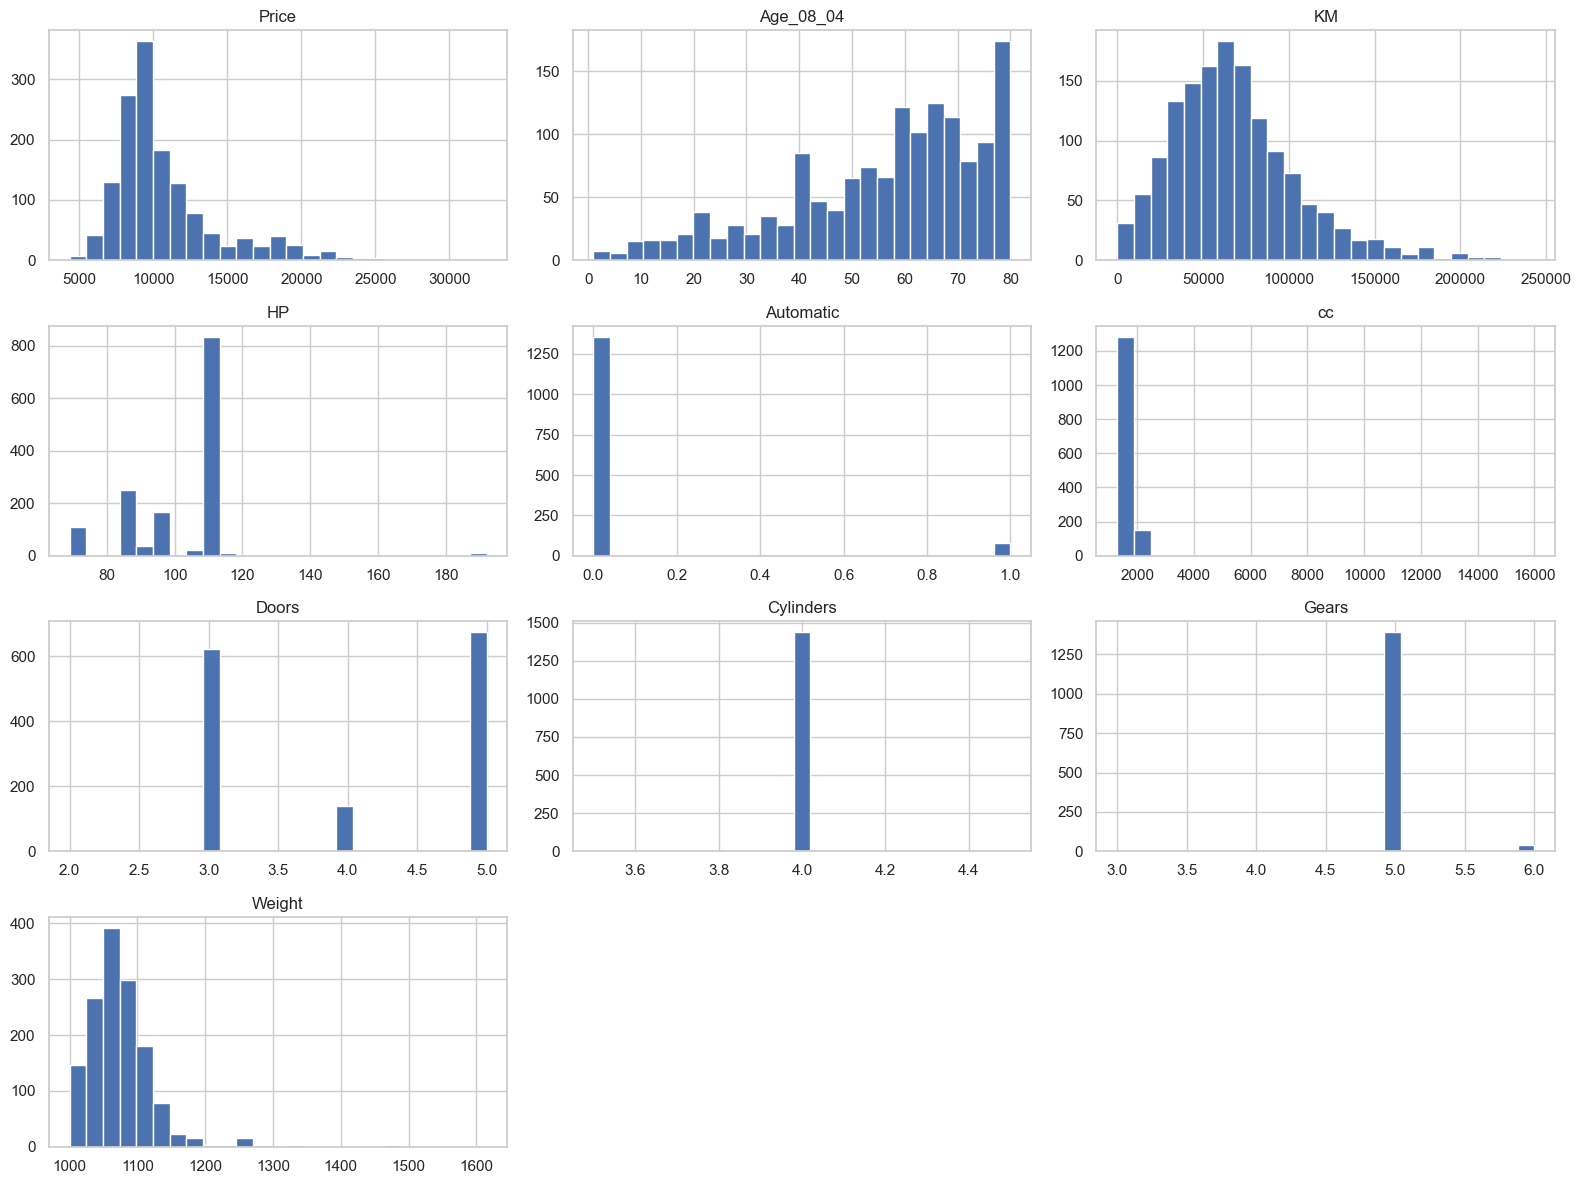

In [8]:
df.hist(figsize=(16, 12), bins=25)
plt.tight_layout()

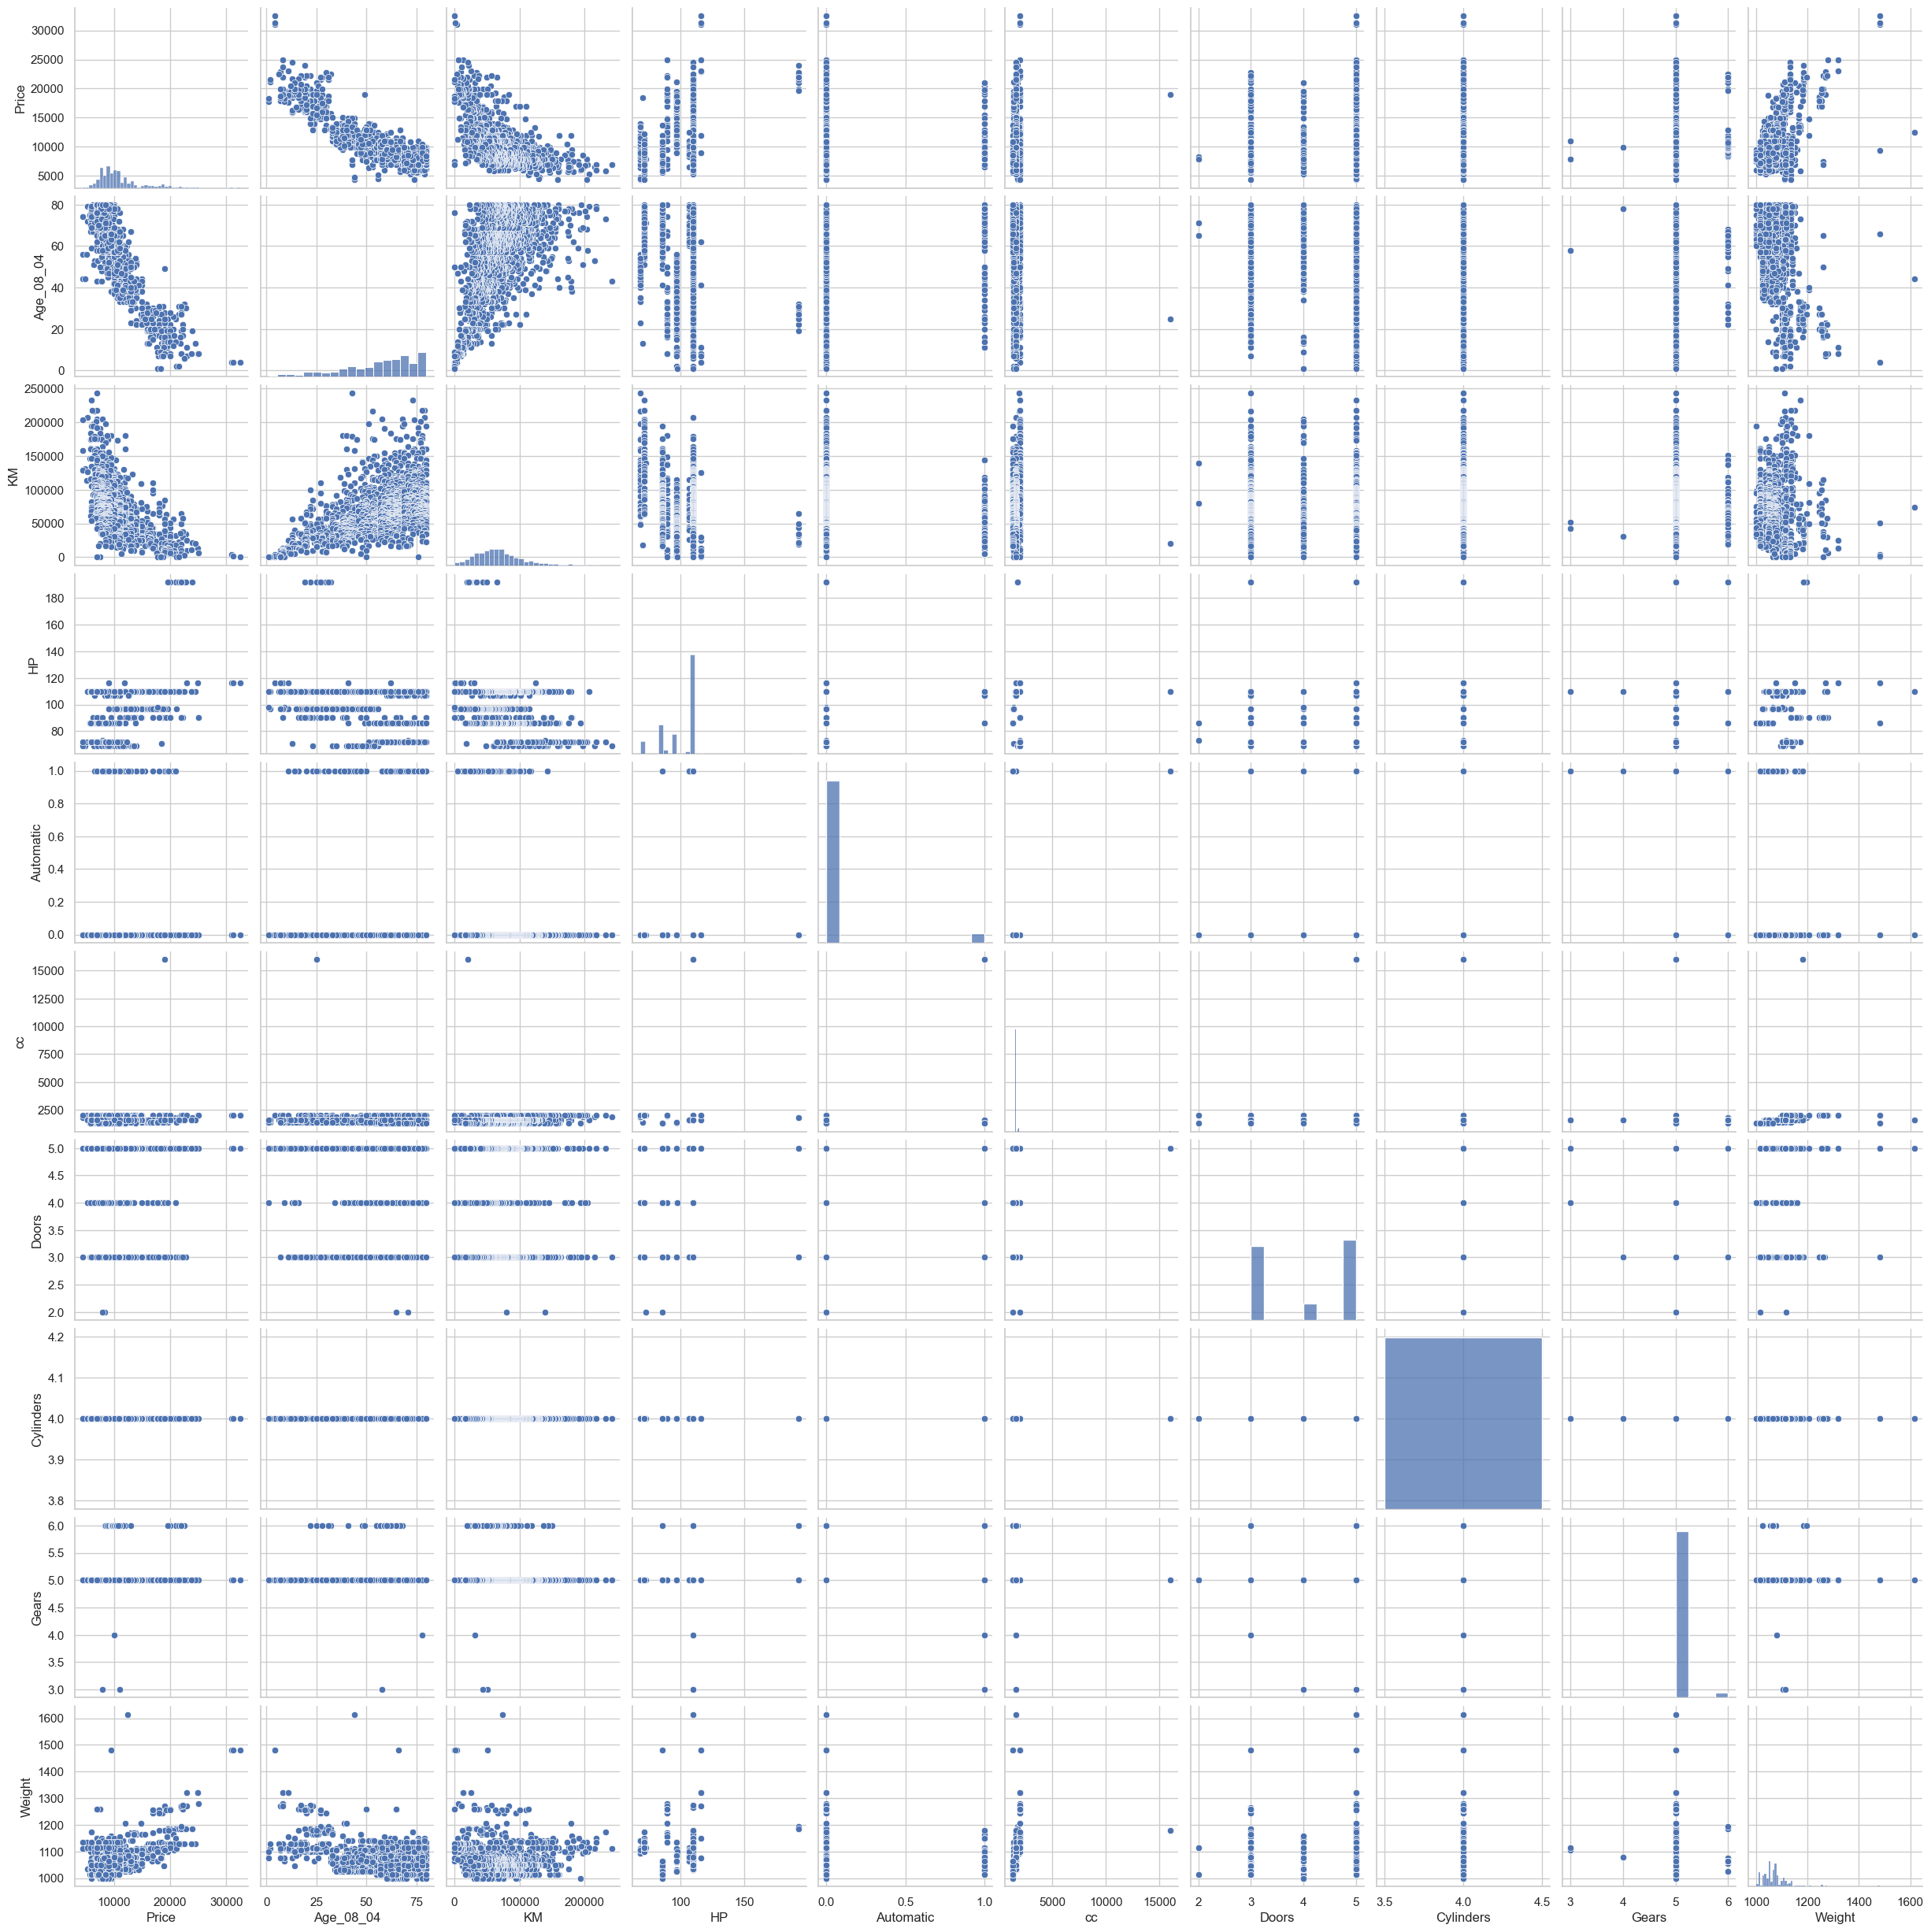

In [9]:
sns.pairplot(df)
plt.show()

Text(0.5, 1.0, 'Outlier Scan')

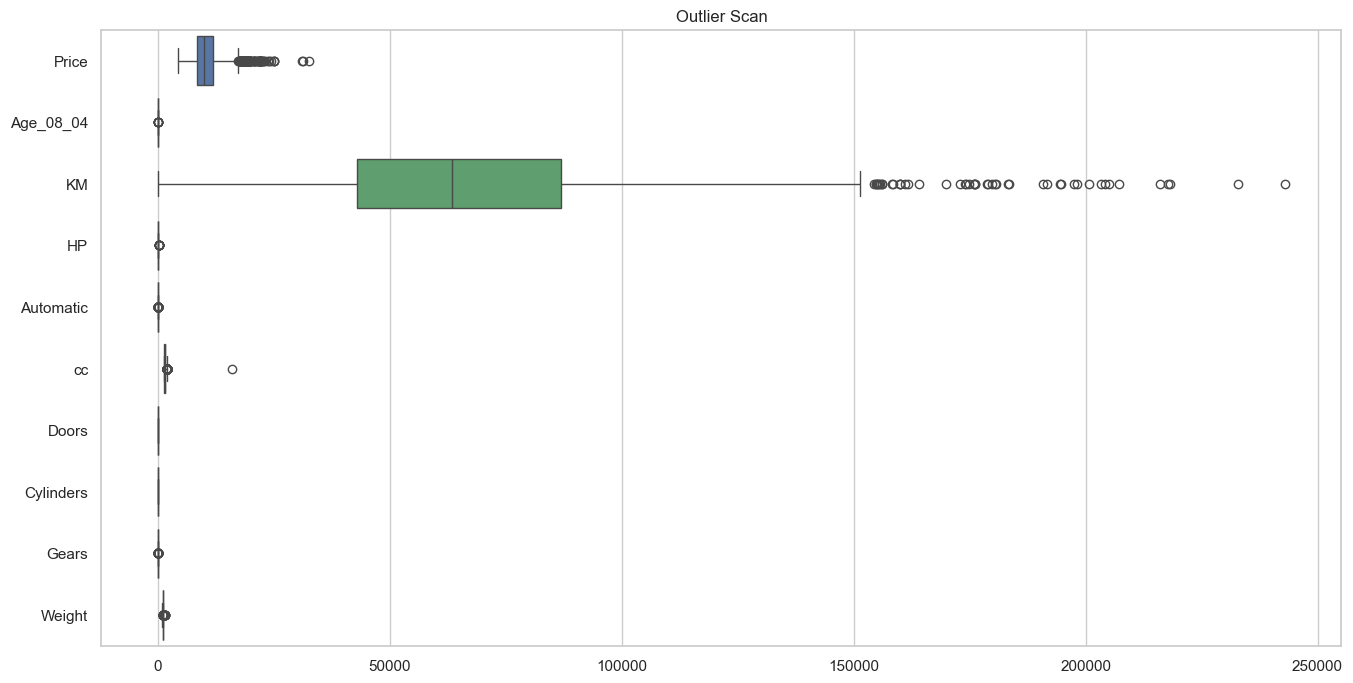

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title('Outlier Scan')


In [12]:
Q1 = df['KM'].quantile(0.25)
Q3 = df['KM'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['KM'] >= lower) & (df['KM'] <= upper)]

Text(0.5, 1.0, 'Outlier Scan')

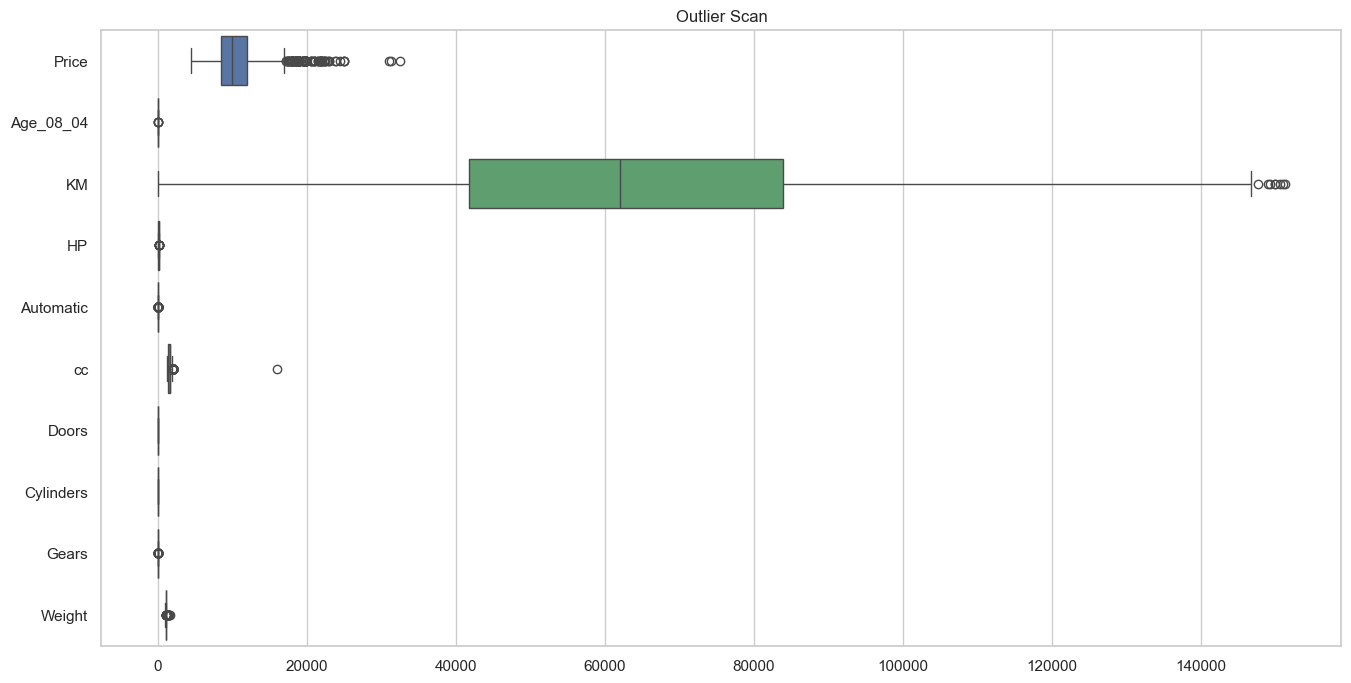

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title('Outlier Scan')


In [14]:

ss=StandardScaler()
le=LabelEncoder()
df['Fuel_Type']=le.fit_transform(df['Fuel_Type'])

In [26]:
target = 'Price'
X = df.drop(columns=[target])
y = df[target]
num_cols = X.select_dtypes(include=np.number).columns
preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols)
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Text(0.5, 1.0, 'Correlation Heatmap')

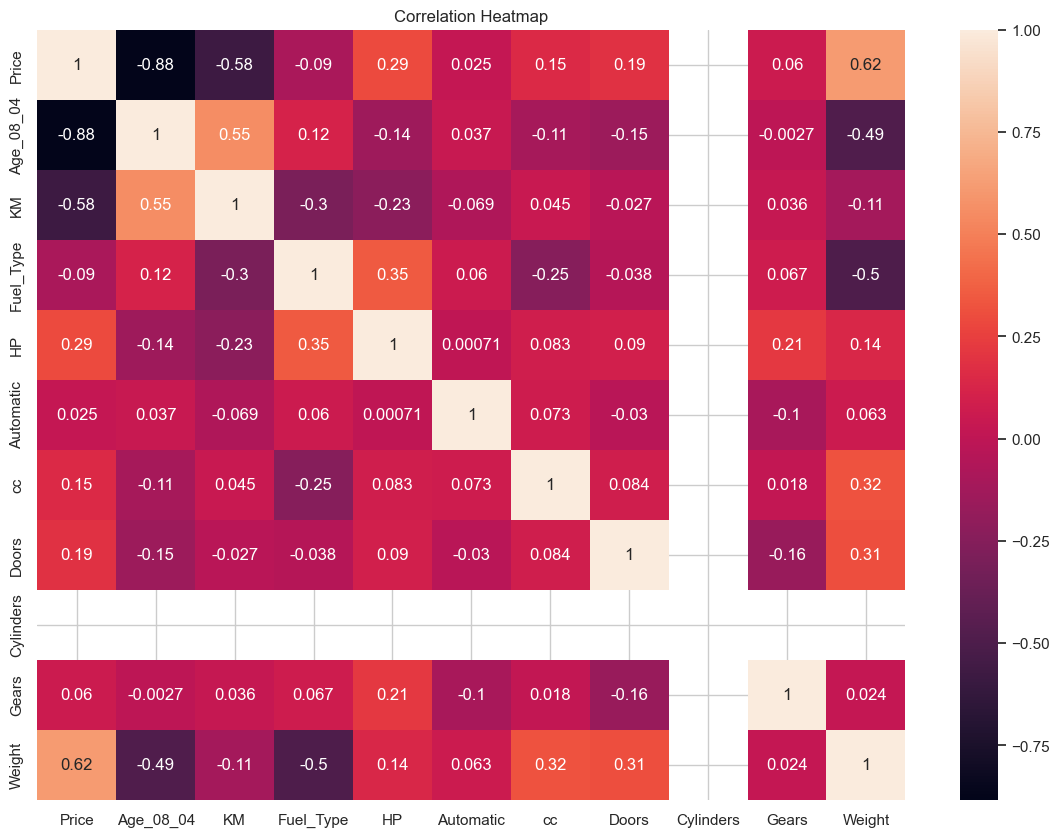

In [29]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')


In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

     Feature          VIF
0  Age_08_04     2.023284
1         KM     1.826099
2  Fuel_Type     2.116969
3         HP     1.410374
4  Automatic     1.062780
5         cc     1.148744
6      Doors     1.190602
7  Cylinders  1737.015543
8      Gears     1.117031
9     Weight     2.322145


## Ridge and Lasso regression help reduce multicollinearity by adding regularization penalties to model coefficients.

In [27]:
models = {'Linear': LinearRegression(), 'Ridge': Ridge(alpha=1.0), 'Lasso': Lasso(alpha=0.01, max_iter=10000)}
results = []
for name, reg in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', reg)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    model = pipe.named_steps['model']
    print(model.coef_)
    results.append([name, r2_score(y_test, pred), mean_absolute_error(y_test, pred), mean_squared_error(y_test, pred)])
pd.DataFrame(results, columns=['Model', 'R2', 'MAE', 'RMSE'])


[-2.39576093e+03 -5.48065273e+02  1.13399180e+02  4.16236522e+02
  7.07753929e+01 -1.06465758e+01 -3.64285015e+01 -8.81072992e-13
  8.00730886e+01  1.00080090e+03]
[-2392.65757096  -549.62469064   112.42119837   416.24284035
    70.58913867   -10.4268861    -35.95258501     0.
    80.18955033  1000.53209554]
[-2395.75660286  -548.06585095   113.38225901   416.23550589
    70.76706214   -10.63325327   -36.41392595     0.
    80.06750349  1000.77747802]


,Model,R2,MAE,RMSE
0,Linear,0.867765,958.451590,1.633036e+06
1,Ridge,0.867780,958.198462,1.632849e+06
2,Lasso,0.867764,958.452028,1.633043e+06


## Interview Notes

Normalization rescales values to a bounded range, often 0-1. Standardization centers values around mean 0 with standard deviation 1. Both help models that depend on distance, gradients, or regularization.
